# Training Raw Data Collection

Collect raw MP150 training recordings into one run folder. Preprocessing and model training are handled separately in `01b_preprocess_train_validate.ipynb`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'acquisition.py').exists():
    ROOT = Path(r'D:/BME/BCI/online_bci/online_eeg')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from acquisition import AcquisitionConfig, collect_training_segments
from plots import plot_raw_recording

print('Pipeline root:', ROOT)

Pipeline root: e:\UCI\BCI\online\online_bci\online_eeg


## Collection Settings

In [2]:
RUN_ID = 'run_003'
RUN_DIR = ROOT / 'runs' / RUN_ID
RAW_DIR = RUN_DIR / 'raw_training'

COLLECT_TRAINING = True
TRAIN_SEGMENT_SEC = 300.0
TRAIN_SEGMENT_NAMES = (f'{RUN_ID}_train',)

EEG_CHANNELS = (1, 2, 3, 4)
EOG_CHANNELS = (5,)
AUDIO_CHANNEL = 16
CHANNEL_NAMES = ('O1', 'Oz', 'O2', 'POz', 'EOG', 'Audio')

ACQ = AcquisitionConfig(
    samplerate=200,
    channels=(*EEG_CHANNELS, *EOG_CHANNELS, AUDIO_CHANNEL),
    chunk_sec=TRAIN_SEGMENT_SEC,
)

RUN_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
print('Run directory:', RUN_DIR)
print('Raw training output:', RAW_DIR)
print('Acquired channels:', ACQ.channels)

Run directory: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_003
Raw training output: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_003\raw_training
Acquired channels: (1, 2, 3, 4, 5, 16)


## Collect Raw Training Segments

Recording started: run_003_train at 2026-06-25 13:14:16 (300.0s, channels=(1, 2, 3, 4, 5, 16))
Elapsed since recording start:  300.0s / 300.0s
Recording ended: run_003_train at 2026-06-25 13:19:16 (elapsed 300.0s)


[WindowsPath('e:/UCI/BCI/online/online_bci/online_eeg/runs/run_003/raw_training/run_003_train.npz')]

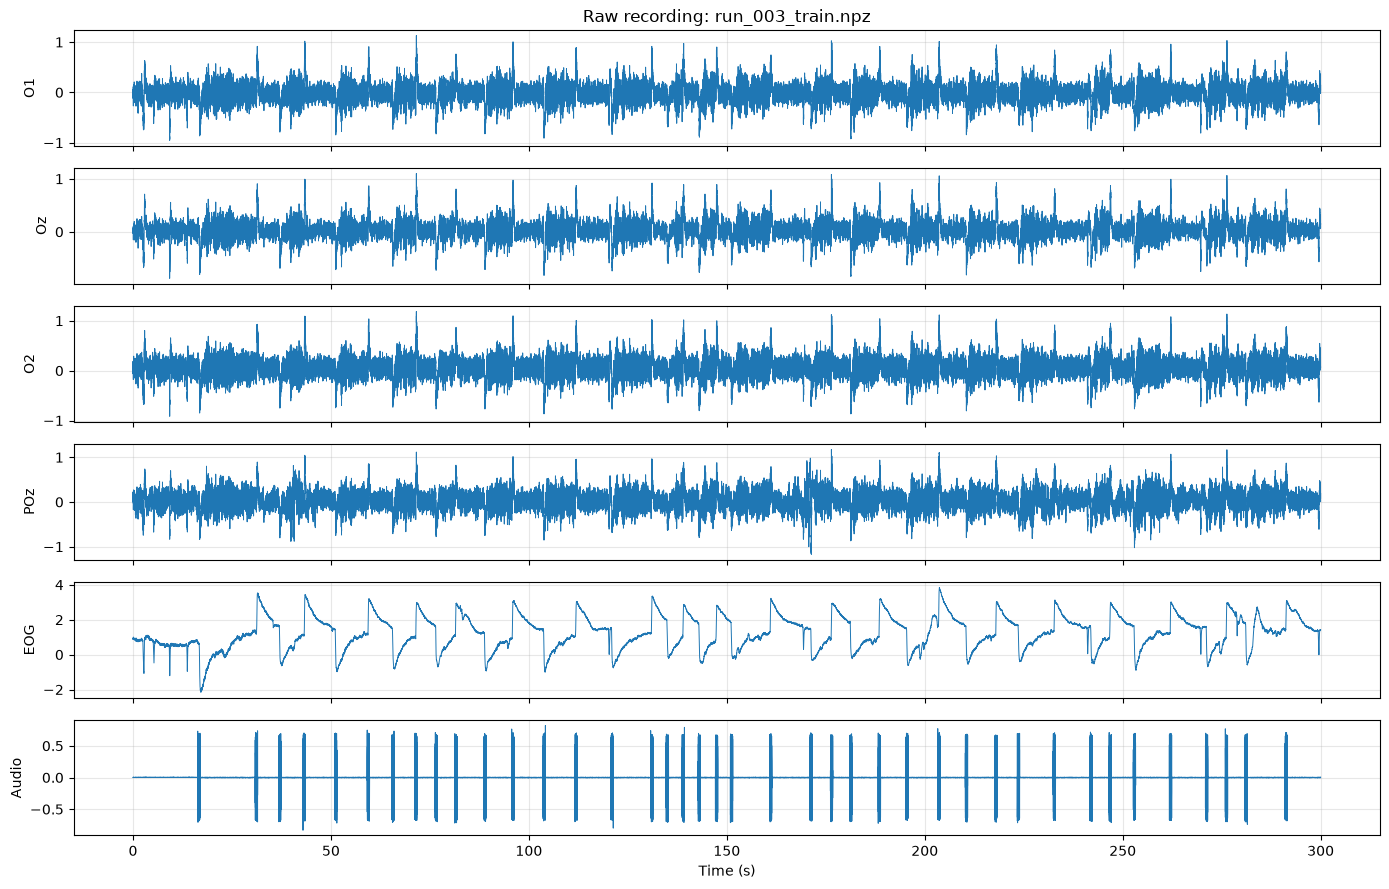

In [3]:
if not COLLECT_TRAINING:
    raise ValueError('Set COLLECT_TRAINING=True when ready to collect raw MP150 training data.')

train_raw_paths = collect_training_segments(
    output_dir=RAW_DIR,
    segment_names=TRAIN_SEGMENT_NAMES,
    config=ACQ,
    duration_sec=TRAIN_SEGMENT_SEC,
)

for raw_path in train_raw_paths:
    fig, axes = plot_raw_recording(raw_path, max_duration_sec=None, channel_names=CHANNEL_NAMES)

train_raw_paths